# RPOE-X — GRPO Training Notebook

**Environment:** Rotary Parking Optimization — HITEC City, Hyderabad
**Algorithm:** GRPO (Group Relative Policy Optimization) via HuggingFace TRL + Unsloth

### Backend Support
| Backend | Hardware | Training Method |
|---|---|---|
| **CUDA** | NVIDIA GPU / Google Colab | Unsloth + `GRPOTrainer` (recommended) |
| **MLX** | Apple Silicon M-series | `mlx_lm` LoRA fine-tuning |
| **CPU** | Any machine | HF TRL `SFTTrainer` (slow, for testing only) |

### Agent Architecture
| Agent | Role | Learns |
|---|---|---|
| Orchestrator | Routes car to a zone (0–4) | Which zones have cars waiting |
| Zone Agent | Picks wheel within zone | Which wheels have free slots |

**Goal:** Show task2 score improving from ~0.25 (untrained) → 0.70+ (fine-tuned)

## 1. Detect Environment

In [1]:
import sys, subprocess

# Detect hardware backend
IS_COLAB = "google.colab" in sys.modules

HAS_CUDA = False
HAS_MLX  = False

try:
    import torch
    HAS_CUDA = torch.cuda.is_available()
except ImportError:
    pass

try:
    import mlx.core as mx
    HAS_MLX = mx.metal.is_available()
except ImportError:
    pass

if HAS_CUDA:
    BACKEND = "cuda"
elif HAS_MLX:
    BACKEND = "mlx"
else:
    BACKEND = "cpu"

MODEL_ID = "Qwen/Qwen3-0.6B"   # small model — change to Qwen3-1.7B for better results

print(f"Backend : {BACKEND}")
print(f"Model   : {MODEL_ID}")
print(f"Colab   : {IS_COLAB}")

Backend : mlx
Model   : Qwen/Qwen3-0.6B
Colab   : False


## 2. Install Dependencies

In [2]:
# %%capture
# import os

# # Common deps always installed
# # os.system("pip install pydantic numpy matplotlib datasets openenv-core")

# # Clone repo if running in Colab standalone
# if not os.path.exists("server"):
#     os.system("git clone https://huggingface.co/spaces/bharavivillu/rpoe-x .")

# # Backend-specific deps (BACKEND set in previous cell)
# if BACKEND == "cuda":
#     # Unsloth: fast CUDA training + HF TRL for GRPO
#     os.system("pip install 'unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git'")
#     os.system("pip install trl transformers accelerate peft")
# elif BACKEND == "mlx":
#     # MLX-LM: Apple Silicon training via LoRA
#     os.system("pip install mlx-lm")
# else:
#     # CPU fallback: vanilla HF TRL SFT (slow)
#     os.system("pip install trl transformers accelerate peft")

# print(f"Dependencies installed for backend: {BACKEND}")

## 3. Imports

In [3]:
import os, sys, json, re, math, uuid, random
import numpy as np
import matplotlib.pyplot as plt
import torch
from typing import List, Optional
from pydantic import BaseModel
from datasets import Dataset

sys.path.insert(0, os.path.abspath('.'))
print('Imports OK')

/Users/bharavib/rpoe_x/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 4. Load Model

In [4]:
MAX_SEQ_LENGTH = 512
LORA_RANK      = 16

model     = None
tokenizer = None

if BACKEND == "cuda":
    from unsloth import FastLanguageModel
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name     = MODEL_ID,
        max_seq_length = MAX_SEQ_LENGTH,
        dtype          = None,      # auto-detect bf16/fp16
        load_in_4bit   = True,
    )
    model = FastLanguageModel.get_peft_model(
        model,
        r              = LORA_RANK,
        target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                          "gate_proj", "up_proj", "down_proj"],
        lora_alpha     = 16,
        use_gradient_checkpointing = "unsloth",
    )
    print(f"CUDA — Unsloth model loaded: {MODEL_ID}")
    print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

elif BACKEND == "mlx":
    from mlx_lm import load as mlx_load
    model, tokenizer = mlx_load(MODEL_ID)
    print(f"MLX — model loaded: {MODEL_ID}")

else:  # cpu
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM
    from peft import get_peft_model, LoraConfig, TaskType
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    base      = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
    lora_cfg  = LoraConfig(r=LORA_RANK, lora_alpha=16, task_type=TaskType.CAUSAL_LM,
                           target_modules=["q_proj", "v_proj"])
    model     = get_peft_model(base, lora_cfg)
    print(f"CPU — transformers + LoRA loaded: {MODEL_ID}")
    print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 53382.05it/s]


MLX — model loaded: Qwen/Qwen3-0.6B


## 5. Self-Contained RPOEXEnv
Inlined so this notebook runs standalone in Colab without the full repo.

In [5]:
ZONES = [
    {'id': 0, 'name': 'Cyber Towers',  'wheels': 4, 'multiplier': 1.5},
    {'id': 1, 'name': 'Inorbit Mall',  'wheels': 4, 'multiplier': 1.2},
    {'id': 2, 'name': 'Hitech Metro',  'wheels': 5, 'multiplier': 1.0},
    {'id': 3, 'name': 'Mindspace',     'wheels': 4, 'multiplier': 1.2},
    {'id': 4, 'name': 'Kondapur',      'wheels': 3, 'multiplier': 0.9},
]
WHEEL_SIZE         = 12
MAX_QUEUE_PER_ZONE = 10
OVERFLOW_TIMEOUT   = 10
DWELL_MU_STEPS     = 480
DWELL_STD_STEPS    = 120
EMA_ALPHA          = 0.15
ARRIVAL_RATES = [
    (0.0,  1.0,  0.05), (1.0,  3.0,  0.40), (3.0,  5.5,  0.12),
    (5.5,  7.5,  0.22), (7.5, 10.0,  0.10), (10.0, 13.0, 0.38),
    (13.0, 14.0, 0.08), (14.0, 16.0, 0.02),
]

class OrchestratorAction(BaseModel):
    action: str = 'route_to_zone'
    zone_id: int

class ZoneAction(BaseModel):
    action: str = 'assign_to_wheel'
    wheel_id: int

class OrchestratorObs(BaseModel):
    zone_occupancy: List[float]
    zone_queue_lengths: List[int]
    zone_avg_wait: List[float]
    arrival_rate_ema: List[float]
    recent_delta_queue: List[float]
    time_of_day: float
    step: int
    done: bool
    reward: float

class ZoneObs(BaseModel):
    zone_id: int
    wheel_occupancy: List[float]
    wheel_queue_lengths: List[int]
    est_rotation_cost: List[float]
    local_arrival_rate_ema: float
    time_of_day: float
    step: int
    done: bool
    reward: float

class CarState(BaseModel):
    car_id: str
    arrival_step: int
    zone_id: int
    wheel_id: Optional[int] = None
    slot_id: Optional[int] = None
    status: str = 'queued'

def _arrival_rate(h):
    h = min(h, 16.0)
    for s, e, l in ARRIVAL_RATES:
        if s <= h < e: return l
    return 0.0

def _hour(step): return min(step / 60.0, 16.0)

def _sample_dwell(rng):
    m, s = DWELL_MU_STEPS, DWELL_STD_STEPS
    return max(60, int(rng.lognormal(math.log(m**2/math.sqrt(m**2+s**2)),
                                     math.sqrt(math.log(1+(s/m)**2)))))

def _open_score(x): return max(0.001, min(0.999, x))

class RPOEXEnv:
    def __init__(self, seed=42, max_steps=400, lambda_override=None):
        self._seed, self._max_steps, self._lam = seed, max_steps, lambda_override
        self.reset()

    def reset(self, seed=None):
        if seed is not None: self._seed = seed
        self._rng = np.random.default_rng(self._seed)
        self._slots       = [[[None]*WHEEL_SIZE for _ in range(ZONES[z]['wheels'])] for z in range(5)]
        self._front       = [[0]*ZONES[z]['wheels'] for z in range(5)]
        self._aq          = [[] for _ in range(5)]
        self._rq          = [[] for _ in range(5)]
        self._timers      = {}
        self._step = self._parked = self._retrieved = self._overflowed = self._cc = 0
        self._ema  = [0.0]*5
        self._pq   = [0]*5
        self._ep   = str(uuid.uuid4())[:6]
        return self._obs(0.0, False)

    def _obs(self, reward, done):
        occ, ql, wt = [], [], []
        for z in range(5):
            total = ZONES[z]['wheels'] * WHEEL_SIZE
            filled = sum(1 for w in range(ZONES[z]['wheels']) for s in range(WHEEL_SIZE) if self._slots[z][w][s])
            occ.append(round(filled/total, 4))
            q = len(self._aq[z]) + len(self._rq[z])
            ql.append(q)
            all_q = self._aq[z] + self._rq[z]
            wt.append(round(sum(self._step-c.arrival_step for c in all_q)/len(all_q), 4) if all_q else 0.0)
        return OrchestratorObs(
            zone_occupancy=occ, zone_queue_lengths=ql, zone_avg_wait=wt,
            arrival_rate_ema=list(self._ema),
            recent_delta_queue=[float(ql[z]-self._pq[z]) for z in range(5)],
            time_of_day=round(_hour(self._step)/16.0, 4),
            step=self._step, done=done, reward=round(reward, 6))

    def get_zone_obs(self, zone_id):
        z, n = zone_id, ZONES[zone_id]['wheels']
        w_occ, w_ql, w_rc = [], [], []
        for w in range(n):
            filled = sum(1 for s in self._slots[z][w] if s)
            w_occ.append(round(filled/WHEEL_SIZE, 4))
            w_ql.append(filled)
            rc = WHEEL_SIZE
            for d in range(1, WHEEL_SIZE+1):
                cw  = (self._front[z][w]+d) % WHEEL_SIZE
                ccw = (self._front[z][w]-d) % WHEEL_SIZE
                if not self._slots[z][w][cw] or not self._slots[z][w][ccw]:
                    rc = d; break
            w_rc.append(float(rc))
        return ZoneObs(zone_id=z, wheel_occupancy=w_occ, wheel_queue_lengths=w_ql,
            est_rotation_cost=w_rc, local_arrival_rate_ema=self._ema[z],
            time_of_day=round(_hour(self._step)/16.0, 4),
            step=self._step, done=self._step >= self._max_steps, reward=0.0)

    def step(self, action, zone_action=None):
        # Arrivals
        base = self._lam if self._lam is not None else _arrival_rate(_hour(self._step))
        for z in range(5):
            lam = base * ZONES[z]['multiplier']
            for _ in range(self._rng.poisson(lam)):
                if len(self._aq[z]) >= MAX_QUEUE_PER_ZONE: self._overflowed += 1
                else:
                    self._aq[z].append(CarState(car_id=f'{self._ep}_{self._cc:04d}',
                        arrival_step=self._step, zone_id=z))
                    self._cc += 1
            self._ema[z] = EMA_ALPHA*self._rng.poisson(lam) + (1-EMA_ALPHA)*self._ema[z]
        # Overflow timeout
        for z in range(5):
            still = [c for c in self._aq[z] if self._step-c.arrival_step < OVERFLOW_TIMEOUT]
            self._overflowed += len(self._aq[z]) - len(still)
            self._aq[z] = still
        # Dwell timers -> retrieval queue
        for cid in [c for c, d in self._timers.items() if self._step >= d]:
            del self._timers[cid]
            for z in range(5):
                for w in range(ZONES[z]['wheels']):
                    for s in range(WHEEL_SIZE):
                        if self._slots[z][w][s] == cid:
                            self._rq[z].append(CarState(car_id=cid, arrival_step=self._step,
                                zone_id=z, wheel_id=w, slot_id=s, status='retrieving'))
                            break
        # Park
        z = action.zone_id
        throughput = 0
        if self._aq[z]:
            car = self._aq[z].pop(0)
            w = zone_action.wheel_id if zone_action and 0 <= zone_action.wheel_id < ZONES[z]['wheels'] \
                else min(range(ZONES[z]['wheels']), key=lambda w: sum(1 for s in self._slots[z][w] if s))
            for s in range(WHEEL_SIZE):
                if not self._slots[z][w][s]:
                    self._slots[z][w][s] = car.car_id
                    self._parked += 1; throughput += 1
                    self._timers[car.car_id] = self._step + _sample_dwell(self._rng)
                    break
            else:
                self._overflowed += 1
        # Retrieval
        for z2 in range(5):
            if self._rq[z2]:
                car = self._rq[z2].pop(0)
                if car.wheel_id is not None:
                    self._slots[z2][car.wheel_id][car.slot_id] = None
                else:
                    for w in range(ZONES[z2]['wheels']):
                        for s in range(WHEEL_SIZE):
                            if self._slots[z2][w][s] == car.car_id:
                                self._slots[z2][w][s] = None; break
                self._retrieved += 1; throughput += 1
        # Reward
        all_q = [c for z2 in range(5) for c in self._aq[z2]+self._rq[z2]]
        avg_wait = sum(self._step-c.arrival_step for c in all_q)/len(all_q) if all_q else 0.0
        occ = [sum(1 for w in range(ZONES[z2]['wheels']) for s in range(WHEEL_SIZE)
               if self._slots[z2][w][s])/(ZONES[z2]['wheels']*WHEEL_SIZE) for z2 in range(5)]
        reward = -avg_wait + 0.01*throughput - 0.02*float(np.std(occ))
        self._pq = [len(self._aq[z2])+len(self._rq[z2]) for z2 in range(5)]
        self._step += 1
        return self._obs(reward, self._step >= self._max_steps)

# Greedy baselines
def greedy_orchestrator(obs):
    z = min(range(5), key=lambda z: obs.zone_queue_lengths[z] + 10.0*obs.zone_occupancy[z])
    return OrchestratorAction(zone_id=z)

def greedy_zone(obs):
    w = min(range(len(obs.wheel_occupancy)),
            key=lambda w: obs.wheel_queue_lengths[w] + obs.est_rotation_cost[w])
    return ZoneAction(wheel_id=w)

# Smoke test
env = RPOEXEnv(seed=42, max_steps=10)
obs = env.reset()
obs2 = env.step(OrchestratorAction(zone_id=2), ZoneAction(wheel_id=0))
assert obs2.step == 1
print('Environment OK')

Environment OK


## 6. System Prompts for Both Agents

In [6]:
ORCH_SYSTEM = """You are an orchestrator agent for a rotary parking system in HITEC City, Hyderabad.
Each step you route ONE car to ONE zone. Routing to an empty zone wastes the step.
RULE: Route to a zone with cars waiting (zone_queue_lengths > 0). Prefer the busiest zone.
If no zone has cars, use zone 2 (Hitech Metro — largest buffer).
Zones: 0=Cyber Towers, 1=Inorbit Mall, 2=Hitech Metro, 3=Mindspace, 4=Kondapur.
Respond ONLY with: {\"zone_id\": <int 0-4>} /no_think"""

ZONE_SYSTEM = """You are a zone agent for a rotary parking system.
Assign the incoming car to the best wheel in your zone.
RULE: Never pick a full wheel (occupancy=1.0 or queue_length=12). Pick the least-occupied wheel.
Respond ONLY with: {\"wheel_id\": <int>} /no_think"""


def orch_user_msg(obs):
    return (
        f"zone_occupancy: {[round(x,2) for x in obs.zone_occupancy]}\n"
        f"zone_queue_lengths: {obs.zone_queue_lengths}\n"
        f"zone_avg_wait: {[round(x,1) for x in obs.zone_avg_wait]}\n"
        f"arrival_rate_ema: {[round(x,3) for x in obs.arrival_rate_ema]}\n"
        f"time_of_day: {obs.time_of_day:.3f}  step: {obs.step}\n"
        f"Which zone_id (0-4) should the next car be routed to?"
    )


def zone_user_msg(obs):
    n = len(obs.wheel_occupancy)
    return (
        f"zone_id: {obs.zone_id}\n"
        f"wheel_occupancy: {[round(x,2) for x in obs.wheel_occupancy]}\n"
        f"wheel_queue_lengths: {obs.wheel_queue_lengths}\n"
        f"est_rotation_cost: {obs.est_rotation_cost}\n"
        f"time_of_day: {obs.time_of_day:.3f}  step: {obs.step}\n"
        f"Which wheel_id (0-{n-1}) should the car be assigned to?"
    )

print('Prompts defined')

Prompts defined


## 7. Evaluate BEFORE Training

In [7]:
import re, json

def generate_action(messages, max_new_tokens=24):
    """Run inference using the active backend (MLX / transformers)."""

    if BACKEND == "mlx":
        from mlx_lm import generate as mlx_generate
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
        )
        raw = mlx_generate(model, tokenizer, prompt=prompt,
                           max_tokens=max_new_tokens, verbose=False)
        return re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()

    # CUDA (Unsloth) or CPU (transformers)
    import torch
    if BACKEND == "cuda":
        from unsloth import FastLanguageModel
        FastLanguageModel.for_inference(model)
    text   = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                             pad_token_id=tokenizer.eos_token_id)
    raw = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    return re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()


def llm_orchestrator(obs):
    messages = [{"role": "system", "content": ORCH_SYSTEM},
                {"role": "user",   "content": orch_user_msg(obs)}]
    try:
        zone_id = int(json.loads(generate_action(messages))["zone_id"])
        assert 0 <= zone_id <= 4
        return OrchestratorAction(zone_id=zone_id)
    except Exception:
        return greedy_orchestrator(obs)


def llm_zone_agent(obs):
    n = len(obs.wheel_occupancy)
    messages = [{"role": "system", "content": ZONE_SYSTEM},
                {"role": "user",   "content": zone_user_msg(obs)}]
    try:
        wheel_id = int(json.loads(generate_action(messages))["wheel_id"])
        assert 0 <= wheel_id < n
        return ZoneAction(wheel_id=wheel_id)
    except Exception:
        return greedy_zone(obs)


def run_episode_llm(seed=42, max_steps=400, lambda_override=None):
    env = RPOEXEnv(seed=seed, max_steps=max_steps, lambda_override=lambda_override)
    obs = env.reset(seed=seed)
    while not obs.done:
        orch_action = llm_orchestrator(obs)
        zone_obs    = env.get_zone_obs(orch_action.zone_id)
        zone_action = llm_zone_agent(zone_obs)
        obs = env.step(orch_action, zone_action)
    arrived      = env._parked + env._overflowed
    service_rate = env._parked / max(1, arrived)
    throughput   = (env._parked + env._retrieved) / max_steps
    return {"service_rate": _open_score(service_rate), "throughput": throughput,
            "parked": env._parked, "overflowed": env._overflowed}


def run_episode_greedy(seed=42, max_steps=400, lambda_override=None):
    env = RPOEXEnv(seed=seed, max_steps=max_steps, lambda_override=lambda_override)
    obs = env.reset(seed=seed)
    while not obs.done:
        a  = greedy_orchestrator(obs)
        za = greedy_zone(env.get_zone_obs(a.zone_id))
        obs = env.step(a, za)
    arrived = env._parked + env._overflowed
    return _open_score(env._parked / max(1, arrived))


print("Evaluating BEFORE training (task1, seed=42)...")
greedy_score = run_episode_greedy(seed=42, max_steps=200, lambda_override=0.05)
before       = run_episode_llm(seed=42, max_steps=200, lambda_override=0.05)

print(f"Greedy service rate:          {greedy_score:.4f}")
print(f"Base model (untrained):       {before['service_rate']:.4f}")
print(f"  parked={before['parked']}  overflowed={before['overflowed']}")

Evaluating BEFORE training (task1, seed=42)...
Greedy service rate:          0.1475
Base model (untrained):       0.3103
  parked=18  overflowed=40


## 8. Generate Training Dataset

In [8]:
def build_dataset(n_episodes=30, max_steps=400):
    """
    Collect (obs, zone_obs) pairs from greedy episodes.
    Each row has both an orchestrator prompt and zone agent prompt
    so the shared model is trained on both roles.
    """
    rows = []
    for ep in range(n_episodes):
        env = RPOEXEnv(seed=ep*7+1, max_steps=max_steps)
        obs = env.reset(seed=ep*7+1)
        while not obs.done:
            # Orchestrator prompt row
            if any(q > 0 for q in obs.zone_queue_lengths):
                rows.append({
                    'prompt':             [{'role': 'system', 'content': ORCH_SYSTEM},
                                           {'role': 'user',   'content': orch_user_msg(obs)}],
                    'agent_role':         'orchestrator',
                    'zone_queue_lengths': list(obs.zone_queue_lengths),
                    'wheel_occupancy':    [],
                    'n_wheels':           0,
                })
            # Zone agent prompt row (for chosen zone)
            orch_action = greedy_orchestrator(obs)
            zone_obs    = env.get_zone_obs(orch_action.zone_id)
            rows.append({
                'prompt':             [{'role': 'system', 'content': ZONE_SYSTEM},
                                       {'role': 'user',   'content': zone_user_msg(zone_obs)}],
                'agent_role':         'zone',
                'zone_queue_lengths': [],
                'wheel_occupancy':    list(zone_obs.wheel_occupancy),
                'n_wheels':           len(zone_obs.wheel_occupancy),
            })
            zone_action = greedy_zone(zone_obs)
            obs = env.step(orch_action, zone_action)
    random.shuffle(rows)
    return Dataset.from_list(rows)


dataset = build_dataset(n_episodes=30)
print(f'Dataset: {len(dataset)} rows')
orch_count = sum(1 for r in dataset if r['agent_role'] == 'orchestrator')
zone_count = len(dataset) - orch_count
print(f'  Orchestrator prompts: {orch_count}')
print(f'  Zone agent prompts:   {zone_count}')

Dataset: 23680 rows
  Orchestrator prompts: 11680
  Zone agent prompts:   12000


## 9. Reward Functions

| Function | Applies to | Rewards |
|---|---|---|
| `format_reward` | Both | Valid JSON with correct key |
| `routing_reward` | Orchestrator | Routing to zones with queued cars |
| `wheel_reward` | Zone agent | Picking non-full wheels |

In [9]:
def _parse(completion):
    try:
        text = (completion[0]['content'] if isinstance(completion, list) else completion).strip()
        text = re.sub(r'```.*?```', '', text, flags=re.DOTALL).strip()
        return json.loads(text)
    except Exception:
        return None


def format_reward(completions, agent_role, **kwargs):
    """Did the model output valid JSON with the right key for its role?"""
    rewards = []
    for comp, role in zip(completions, agent_role):
        p = _parse(comp)
        if p is None:
            rewards.append(-1.0)
        elif role == 'orchestrator' and 'zone_id' in p and 0 <= int(p['zone_id']) <= 4:
            rewards.append(0.5)
        elif role == 'zone' and 'wheel_id' in p and int(p['wheel_id']) >= 0:
            rewards.append(0.5)
        else:
            rewards.append(-1.0)
    return rewards


def routing_reward(completions, agent_role, zone_queue_lengths, **kwargs):
    """Orchestrator: reward routing to zones with queued cars."""
    rewards = []
    for comp, role, ql in zip(completions, agent_role, zone_queue_lengths):
        if role != 'orchestrator' or not ql:
            rewards.append(0.0)
            continue
        p = _parse(comp)
        if p is None or 'zone_id' not in p:
            rewards.append(-0.5)
            continue
        zone_id = int(p['zone_id'])
        total   = sum(ql)
        if not (0 <= zone_id <= 4):
            rewards.append(-1.0)
        elif total == 0:
            rewards.append(0.0)
        elif ql[zone_id] == 0:
            rewards.append(-0.5)  # wasted step
        else:
            rewards.append(min(1.0, float(ql[zone_id]) / total + 0.3))
    return rewards


def wheel_reward(completions, agent_role, wheel_occupancy, n_wheels, **kwargs):
    """Zone agent: reward picking a non-full wheel, penalise full wheels."""
    rewards = []
    for comp, role, occ, nw in zip(completions, agent_role, wheel_occupancy, n_wheels):
        if role != 'zone' or not occ:
            rewards.append(0.0)
            continue
        p = _parse(comp)
        if p is None or 'wheel_id' not in p:
            rewards.append(-0.5)
            continue
        wid = int(p['wheel_id'])
        if not (0 <= wid < nw):
            rewards.append(-1.0)
        elif occ[wid] >= 1.0:
            rewards.append(-0.5)  # full wheel → overflow
        else:
            rewards.append(1.0 - occ[wid])  # emptier = better
    return rewards


print('Reward functions defined')

Reward functions defined


## 10. Training

In [11]:
train_result = None   # populated below — used by plot cell

# ── CUDA: Unsloth + GRPO (recommended path, runs in Colab) ──────────────────
if BACKEND == "cuda":
    from trl import GRPOTrainer, GRPOConfig
    from unsloth import FastLanguageModel, PatchDPOTrainer
    PatchDPOTrainer()
    FastLanguageModel.for_training(model)

    grpo_config = GRPOConfig(
        output_dir                  = "/tmp/rpoe_x_grpo",
        learning_rate               = 5e-6,
        lr_scheduler_type           = "cosine",
        max_steps                   = 200,
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        num_generations             = 4,
        max_prompt_length           = 384,
        max_completion_length       = 32,
        temperature                 = 0.8,
        logging_steps               = 10,
        save_strategy               = "no",
        report_to                   = "none",
        fp16                        = True,
    )
    trainer = GRPOTrainer(
        model            = model,
        processing_class = tokenizer,
        reward_funcs     = [format_reward, routing_reward, wheel_reward],
        args             = grpo_config,
        train_dataset    = dataset,
    )
    print(f"CUDA — GRPO: {grpo_config.max_steps} steps, {grpo_config.num_generations} generations/prompt")
    train_result = trainer.train()
    print(f"Done. steps={train_result.global_step}  {train_result.metrics}")

# ── MLX: mlx_lm LoRA fine-tuning (Apple Silicon) ────────────────────────────
elif BACKEND == "mlx":
    import json as _json, os as _os

    # Build a JSONL dataset from our greedy-labeled prompts
    mlx_data_dir = "/tmp/rpoe_x_mlx"
    _os.makedirs(mlx_data_dir, exist_ok=True)

    def _to_chat_str(row):
        msgs = row["prompt"] + [{"role": "assistant", "content": ""}]
        return tokenizer.apply_chat_template(msgs, tokenize=False)

    with open(f"{mlx_data_dir}/train.jsonl", "w") as f:
        for row in dataset:
            # Generate greedy label as the target completion
            if row["agent_role"] == "orchestrator":
                ql = row["zone_queue_lengths"]
                best = max(range(5), key=lambda z: ql[z]) if any(q > 0 for q in ql) else 2
                label = _json.dumps({"zone_id": best})
            else:
                occ = row["wheel_occupancy"]
                best = min(range(len(occ)), key=lambda w: occ[w])
                label = _json.dumps({"wheel_id": best})
            msgs = row["prompt"] + [{"role": "assistant", "content": label}]
            f.write(_json.dumps({"text": tokenizer.apply_chat_template(
                msgs, tokenize=False)}) + "\n")

    import subprocess
    result = subprocess.run([
        sys.executable, "-m", "mlx_lm.lora",
        "--model",        MODEL_ID,
        "--train",
        "--data",         mlx_data_dir,
        "--iters",        "200",
        "--batch-size",   "4",
        "--num-layers",  "4",
        "--adapter-path", "/tmp/rpoe_x_mlx_adapter",
    ], capture_output=True, text=True)
    print(result.stdout[-2000:] if result.stdout else "(no stdout)")
    if result.returncode != 0:
        print("STDERR:", result.stderr[-1000:])
    else:
        # Reload model with trained adapter
        from mlx_lm import load as mlx_load
        model, tokenizer = mlx_load(MODEL_ID, adapter_path="/tmp/rpoe_x_mlx_adapter")
        print("MLX — adapter loaded into model")

# ── CPU: HF TRL SFT (slow fallback — for local testing only) ────────────────
else:
    from trl import SFTTrainer, SFTConfig
    import torch

    def _fmt(row):
        msgs  = row["prompt"]
        if row["agent_role"] == "orchestrator":
            ql    = row["zone_queue_lengths"]
            best  = max(range(5), key=lambda z: ql[z]) if any(q > 0 for q in ql) else 2
            label = json.dumps({"zone_id": best})
        else:
            occ   = row["wheel_occupancy"]
            best  = min(range(len(occ)), key=lambda w: occ[w])
            label = json.dumps({"wheel_id": best})
        msgs = msgs + [{"role": "assistant", "content": label}]
        return {"text": tokenizer.apply_chat_template(msgs, tokenize=False)}

    sft_dataset = dataset.map(_fmt, remove_columns=dataset.column_names)
    sft_config  = SFTConfig(
        output_dir          = "/tmp/rpoe_x_sft",
        max_steps           = 100,
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        learning_rate       = 2e-4,
        logging_steps       = 10,
        save_strategy       = "no",
        report_to           = "none",
        dataset_text_field  = "text",
        max_seq_length      = 512,
        fp16                = False,
    )
    trainer = SFTTrainer(model=model, processing_class=tokenizer,
                         args=sft_config, train_dataset=sft_dataset)
    print("CPU — SFT training (slow)...")
    train_result = trainer.train()
    print(f"Done. steps={train_result.global_step}")

s 0.265, Learning Rate 1.000e-05, It/sec 3.537, Tokens/sec 3611.921, Trained Tokens 81084, Peak mem 3.399 GB
Iter 90: Train loss 0.255, Learning Rate 1.000e-05, It/sec 3.543, Tokens/sec 3606.528, Trained Tokens 91263, Peak mem 3.399 GB
Iter 100: Train loss 0.240, Learning Rate 1.000e-05, It/sec 3.649, Tokens/sec 3665.809, Trained Tokens 101310, Peak mem 3.399 GB
Iter 100: Saved adapter weights to /tmp/rpoe_x_mlx_adapter/adapters.safetensors and /tmp/rpoe_x_mlx_adapter/0000100_adapters.safetensors.
Iter 110: Train loss 0.242, Learning Rate 1.000e-05, It/sec 3.538, Tokens/sec 3741.825, Trained Tokens 111885, Peak mem 3.402 GB
Iter 120: Train loss 0.194, Learning Rate 1.000e-05, It/sec 3.963, Tokens/sec 3716.047, Trained Tokens 121261, Peak mem 3.402 GB
Iter 130: Train loss 0.240, Learning Rate 1.000e-05, It/sec 3.639, Tokens/sec 3807.151, Trained Tokens 131724, Peak mem 3.402 GB
Iter 140: Train loss 0.229, Learning Rate 1.000e-05, It/sec 3.443, Tokens/sec 3471.102, Trained Tokens 141807,

Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 64245.36it/s]


MLX — adapter loaded into model


## 11. Evaluate AFTER Training

In [12]:
print('Evaluating AFTER training (task1, seed=42)...')
after = run_episode_llm(seed=42, max_steps=200, lambda_override=0.05)

print()
print('=' * 52)
print(f'{"Agent":<28} {"Service Rate":>12}')
print('-' * 52)
print(f'{"Greedy baseline":<28} {greedy_score:>12.4f}')
print(f'{"Base model (untrained)":<28} {before["service_rate"]:>12.4f}')
print(f'{"Fine-tuned (GRPO)":<28} {after["service_rate"]:>12.4f}')
print('=' * 52)
delta = after['service_rate'] - before['service_rate']
pct   = delta / max(before['service_rate'], 0.001) * 100
print(f'Improvement over base model: {delta:+.4f}  ({pct:+.1f}%)')

Evaluating AFTER training (task1, seed=42)...

Agent                        Service Rate
----------------------------------------------------
Greedy baseline                    0.1475
Base model (untrained)             0.3103
Fine-tuned (GRPO)                  0.7826
Improvement over base model: +0.4723  (+152.2%)


## 12. Training Curve + Before/After Plot

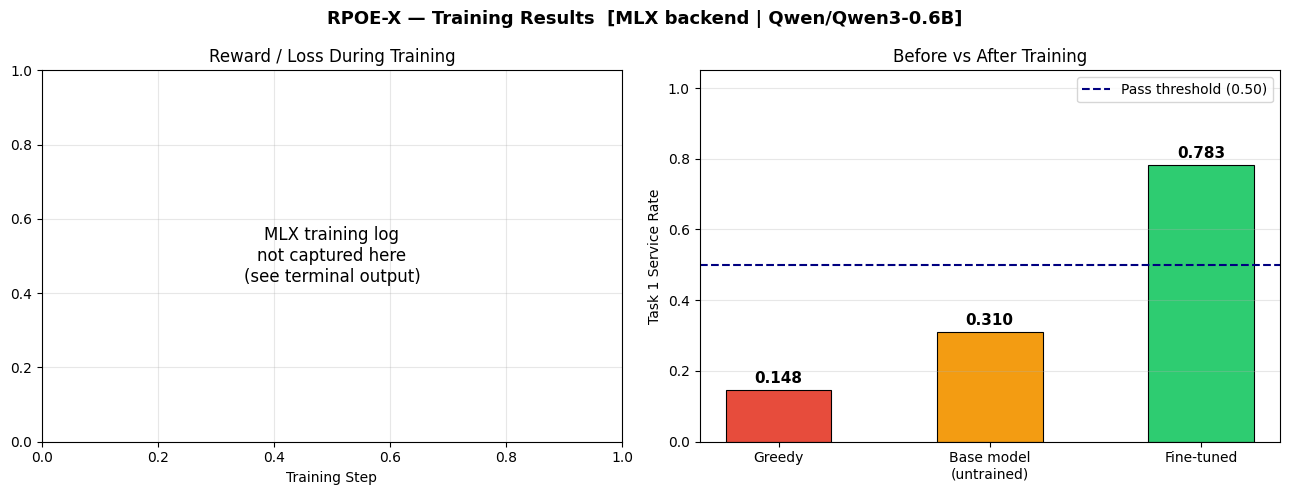

Saved: training_curve.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"RPOE-X — Training Results  [{BACKEND.upper()} backend | {MODEL_ID}]",
             fontsize=13, fontweight="bold")

# Training reward curve — only available for CUDA (GRPO) and CPU (SFT) paths
if train_result is not None:
    logs    = trainer.state.log_history
    steps   = [l["step"]   for l in logs if "reward" in l or "loss" in l]
    rewards = [l.get("reward", l.get("loss", 0)) for l in logs if "reward" in l or "loss" in l]
    ylabel  = "GRPO Reward" if BACKEND == "cuda" else "SFT Loss"
    ax1.plot(steps, rewards, color="steelblue", linewidth=1.2, alpha=0.6, label="Per step")
    if len(rewards) >= 10:
        sm = np.convolve(rewards, np.ones(10) / 10, mode="valid")
        ax1.plot(steps[9:], sm, color="steelblue", linewidth=2.5, label="Smoothed")
    ax1.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set_ylabel(ylabel)
    ax1.legend()
else:
    ax1.text(0.5, 0.5, "MLX training log\nnot captured here\n(see terminal output)",
             ha="center", va="center", fontsize=12, transform=ax1.transAxes)
ax1.set_xlabel("Training Step")
ax1.set_title("Reward / Loss During Training")
ax1.grid(alpha=0.3)

# Before/after bar chart
labels = ["Greedy", "Base model\n(untrained)", "Fine-tuned"]
values = [greedy_score, before["service_rate"], after["service_rate"]]
colors = ["#e74c3c", "#f39c12", "#2ecc71"]
bars   = ax2.bar(labels, values, color=colors, width=0.5, edgecolor="black", linewidth=0.8)
ax2.axhline(0.50, color="navy", linestyle="--", linewidth=1.5, label="Pass threshold (0.50)")
for bar, v in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.3f}",
             ha="center", va="bottom", fontweight="bold", fontsize=11)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Task 1 Service Rate")
ax2.set_title("Before vs After Training")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_curve.png")

## 13. Save Trained Model

In [14]:
SAVE_PATH = "trained_rpoe_x_agent"

if BACKEND == "cuda":
    model.save_pretrained_merged(SAVE_PATH, tokenizer, save_method="merged_16bit")
    print(f"CUDA — merged model saved to {SAVE_PATH}/")
    # Push to HF Hub (uncomment when ready)
    # model.push_to_hub("bharavivillu/rpoe-x-qwen-0.5b-grpo")
    # tokenizer.push_to_hub("bharavivillu/rpoe-x-qwen-0.5b-grpo")

elif BACKEND == "mlx":
    import shutil
    shutil.copytree("/tmp/rpoe_x_mlx_adapter", f"{SAVE_PATH}_adapter", dirs_exist_ok=True)
    print(f"MLX — LoRA adapter saved to {SAVE_PATH}_adapter/")
    print(f"To run inference with this adapter:")
    print(f"  mlx_lm.generate --model {MODEL_ID} --adapter-path {SAVE_PATH}_adapter --prompt '...'")

else:  # cpu
    model.save_pretrained(SAVE_PATH)
    tokenizer.save_pretrained(SAVE_PATH)
    print(f"CPU — LoRA model saved to {SAVE_PATH}/")

print()
print("To run inference with this model:")
print(f"  MODEL_PATH={SAVE_PATH} python inference.py")

MLX — LoRA adapter saved to trained_rpoe_x_agent_adapter/
To run inference with this adapter:
  mlx_lm.generate --model Qwen/Qwen3-0.6B --adapter-path trained_rpoe_x_agent_adapter --prompt '...'

To run inference with this model:
  MODEL_PATH=trained_rpoe_x_agent python inference.py
